# Variogram Parameter Selection

Data-driven justification for variogram fitting parameters:
1. Station network geometry (domain size, density)
2. Pairwise distance distribution → `max_lag_km`
3. Nearest-neighbor distances → minimum bin width
4. Bin occupancy comparison across parameter sets
5. Final recommendations vs. E-OBS literature values

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer
from scipy.spatial.distance import pdist
from sklearn.neighbors import NearestNeighbors

ROOT = Path.cwd().parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

from thesis.config import Config
from thesis.data.registry import DataRegistry

cfg = Config()
registry = DataRegistry.from_config(cfg)

## 1. Station Network Geometry

Stations: 4986
Domain: 425 × 409 km
Diagonal: 590 km


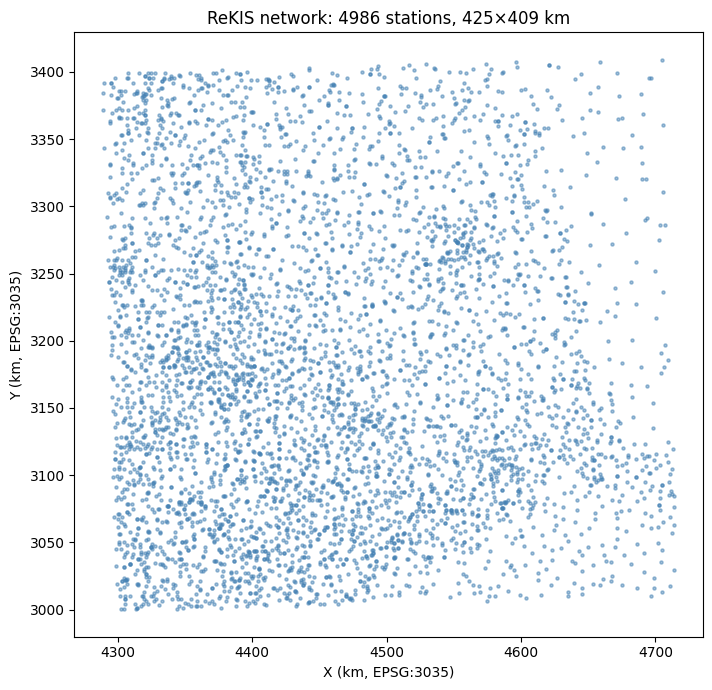

In [2]:
stations = registry.stations.load_stations()

transformer = Transformer.from_crs("EPSG:4326", cfg.study_area.target_crs, always_xy=True)
x_proj, y_proj = transformer.transform(stations["lon"].values, stations["lat"].values)
coords = np.column_stack([x_proj, y_proj])

x_range_km = (x_proj.max() - x_proj.min()) / 1000
y_range_km = (y_proj.max() - y_proj.min()) / 1000
diag_km = np.sqrt(x_range_km**2 + y_range_km**2)

print(f"Stations: {len(stations)}")
print(f"Domain: {x_range_km:.0f} × {y_range_km:.0f} km")
print(f"Diagonal: {diag_km:.0f} km")

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(x_proj / 1000, y_proj / 1000, s=5, alpha=0.5, color="steelblue")
ax.set_xlabel("X (km, EPSG:3035)")
ax.set_ylabel("Y (km, EPSG:3035)")
ax.set_title(f"ReKIS network: {len(stations)} stations, {x_range_km:.0f}×{y_range_km:.0f} km")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 2. Pairwise Distance Distribution

Total pairs: 12,427,605
Min:    0.0 km
Median: 187.6 km
p90:    324.7 km
p95:    358.0 km
p99:    414.0 km
Max:    574.2 km


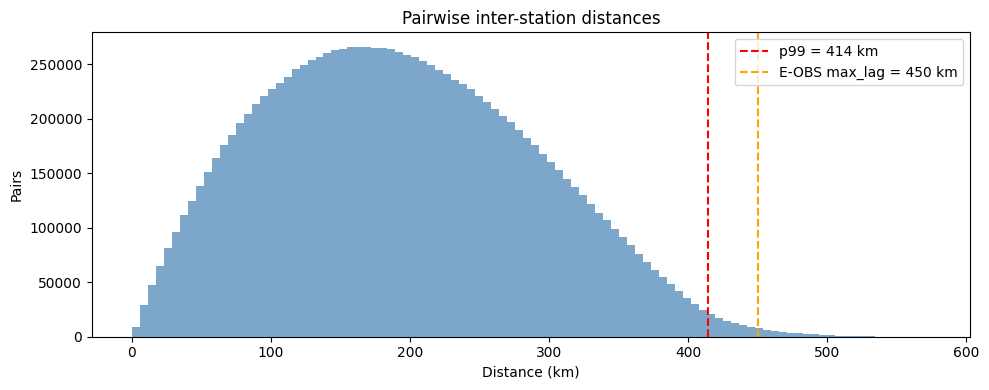

In [3]:
all_dists_km = pdist(coords) / 1000

print(f"Total pairs: {len(all_dists_km):,}")
print(f"Min:    {all_dists_km.min():.1f} km")
print(f"Median: {np.median(all_dists_km):.1f} km")
print(f"p90:    {np.percentile(all_dists_km, 90):.1f} km")
print(f"p95:    {np.percentile(all_dists_km, 95):.1f} km")
print(f"p99:    {np.percentile(all_dists_km, 99):.1f} km")
print(f"Max:    {all_dists_km.max():.1f} km")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_dists_km, bins=100, color="steelblue", edgecolor="none", alpha=0.7)
ax.axvline(np.percentile(all_dists_km, 99), color="red", ls="--",
           label=f"p99 = {np.percentile(all_dists_km, 99):.0f} km")
ax.axvline(450, color="orange", ls="--", label="E-OBS max_lag = 450 km")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Pairs")
ax.set_title("Pairwise inter-station distances")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Nearest-Neighbor Distances

Nearest-neighbor distance:
  Min:    0.0 km
  Median: 2.1 km
  p75:    3.7 km
  p90:    5.0 km
  Max:    18.4 km


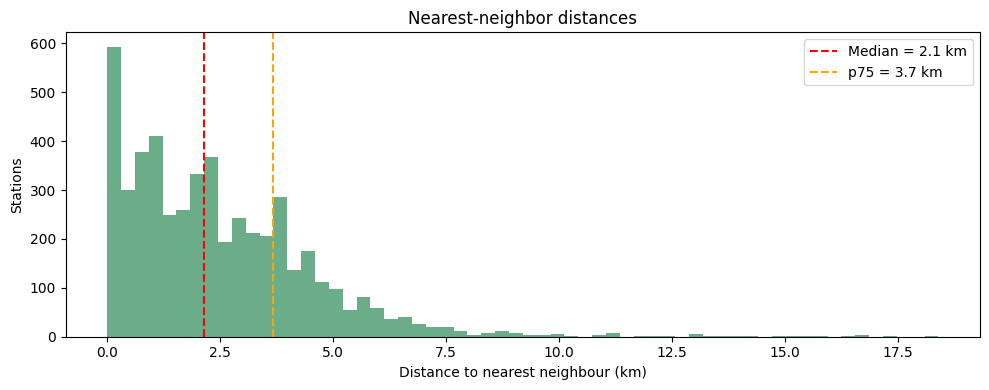

In [4]:
nn = NearestNeighbors(n_neighbors=2, algorithm="ball_tree").fit(coords)
nn_distances, _ = nn.kneighbors(coords)
nn_km = nn_distances[:, 1] / 1000

print(f"Nearest-neighbor distance:")
print(f"  Min:    {nn_km.min():.1f} km")
print(f"  Median: {np.median(nn_km):.1f} km")
print(f"  p75:    {np.percentile(nn_km, 75):.1f} km")
print(f"  p90:    {np.percentile(nn_km, 90):.1f} km")
print(f"  Max:    {nn_km.max():.1f} km")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(nn_km, bins=60, color="seagreen", edgecolor="none", alpha=0.7)
ax.axvline(np.median(nn_km), color="red", ls="--", label=f"Median = {np.median(nn_km):.1f} km")
ax.axvline(np.percentile(nn_km, 75), color="orange", ls="--",
           label=f"p75 = {np.percentile(nn_km, 75):.1f} km")
ax.set_xlabel("Distance to nearest neighbour (km)")
ax.set_ylabel("Stations")
ax.set_title("Nearest-neighbor distances")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Bin Occupancy Comparison

Each variogram bin needs at least `MIN_PAIRS` station pairs for a robust
semi-variance estimate. Compare three parameter sets.

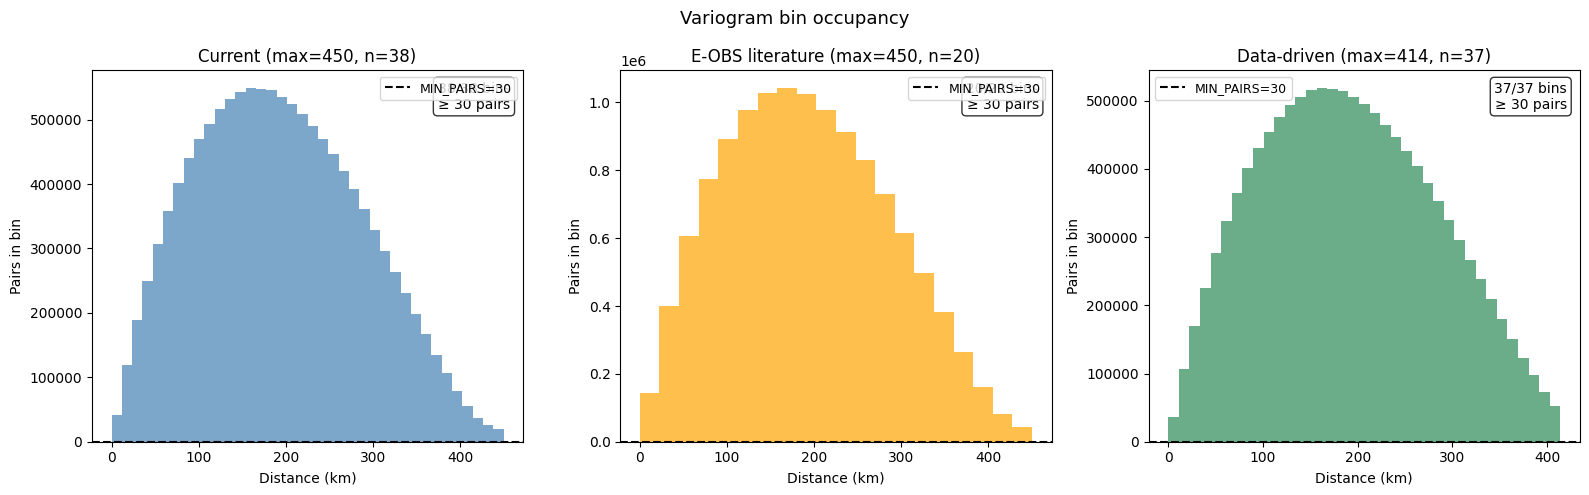

In [5]:
MIN_PAIRS = 30

# Data-driven parameters
max_lag_data = np.percentile(all_dists_km, 99)
bin_width_data = np.percentile(nn_km, 75) * 3
n_lags_data = max(10, int(max_lag_data / bin_width_data))

configs = [
    ("Current (max=450, n=38)", 450, 38, "steelblue"),
    ("E-OBS literature (max=450, n=20)", 450, 20, "orange"),
    (f"Data-driven (max={max_lag_data:.0f}, n={n_lags_data})", max_lag_data, n_lags_data, "seagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, max_lag, n_lags, color) in zip(axes, configs):
    edges = np.linspace(0, max_lag, n_lags + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    counts, _ = np.histogram(all_dists_km, bins=edges)

    ax.bar(centers, counts, width=edges[1] - edges[0], color=color, alpha=0.7, edgecolor="none")
    ax.axhline(MIN_PAIRS, color="black", ls="--", lw=1.5, label=f"MIN_PAIRS={MIN_PAIRS}")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Pairs in bin")
    ax.set_title(label)
    ax.legend(fontsize=9)

    n_ok = (counts >= MIN_PAIRS).sum()
    ax.text(0.97, 0.97, f"{n_ok}/{n_lags} bins\n≥ {MIN_PAIRS} pairs",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("Variogram bin occupancy", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Summary & Chosen Parameters

In [8]:
print(f"  max_lag_km   = {cfg.kriging.search_radius_km:.0f} km  (config)")
print(f"  n_lags       = 38")
print(f"  min_pairs    = 30")
print()
print("JUSTIFICATION:")
print(f"  Domain diagonal:    {diag_km:.0f} km")
print(f"  p99 pairwise dist:  {np.percentile(all_dists_km, 99):.0f} km")
print(f"  Median NN dist:     {np.median(nn_km):.1f} km → min bin width ~ {np.median(nn_km)*2:.0f} km")
print(f"  Bin width (n=38):   {cfg.kriging.search_radius_km / 38 * 1000 / 1000:.1f} km")

  max_lag_km   = 416 km  (config)
  n_lags       = 38
  min_pairs    = 30

JUSTIFICATION:
  Domain diagonal:    590 km
  p99 pairwise dist:  414 km
  Median NN dist:     2.1 km → min bin width ~ 4 km
  Bin width (n=38):   10.9 km
